# Task
Perform sentiment analysis on the "user_reviews.csv" dataset using a BiLSTM model. The relevant columns are "Translated_Review" for text and "Sentiment" for sentiment labels. Preprocess the data by removing rows with 'nan' values in either of these columns. Split the data into 70% training and 30% testing sets. Train the BiLSTM model and finetune it to achieve the best possible accuracy.

## Load and preprocess the data

### Subtask:
Load the `user_reviews.csv` dataset, handle missing values in the `Translated_Review` and `Sentiment` columns, and prepare the text data for the BiLSTM model by tokenizing and padding the sequences.


**Reasoning**:
Load the dataset and preprocess the data as requested in the instructions. This includes handling missing values, converting sentiment labels to numerical format, tokenizing the text data, and padding the sequences for uniform length.



In [1]:
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load the dataset
df = pd.read_csv('/content/user_reviews.csv')

# Remove rows with missing values in 'Translated_Review' or 'Sentiment'
df.dropna(subset=['Translated_Review', 'Sentiment'], inplace=True)

# Convert 'Sentiment' to numerical labels
sentiment_mapping = {'Positive': 2, 'Neutral': 1, 'Negative': 0}
df['Sentiment'] = df['Sentiment'].map(sentiment_mapping)

# Tokenize the 'Translated_Review' column
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['Translated_Review'])
sequences = tokenizer.texts_to_sequences(df['Translated_Review'])

# Pad the sequences
max_len = 100  # Define a fixed sequence length
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

# Display the first few rows of the processed data and the shape of padded sequences
print("Processed DataFrame:")
display(df.head())
print("\nShape of padded sequences:")
print(padded_sequences.shape)

Processed DataFrame:


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,2,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,2,0.25,0.288462
3,10 Best Foods for You,Works great especially going grocery store,2,0.40,0.875000
4,10 Best Foods for You,Best idea us,2,1.00,0.300000
5,10 Best Foods for You,Best way,2,1.00,0.300000



Shape of padded sequences:
(37427, 100)


**Reasoning**:
The data has been loaded, cleaned, and preprocessed for the BiLSTM model. The next step is to split the data into training and testing sets.



In [2]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, df['Sentiment'], test_size=0.3, random_state=42)

# Display the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (26198, 100)
Shape of X_test: (11229, 100)
Shape of y_train: (26198,)
Shape of y_test: (11229,)


## Build the bilstm model

### Subtask:
Create a BiLSTM model for sentiment analysis.


**Reasoning**:
Create a BiLSTM model using the Sequential API with Embedding, Bidirectional LSTM, Dense, and Dropout layers, then print the model summary.



In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

# Get vocabulary size from the fitted tokenizer
vocab_size = len(tokenizer.word_index) + 1

# Define embedding dimension
embedding_dim = 128

# Create the Sequential model
model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    Bidirectional(LSTM(64)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax') # 3 classes for sentiment analysis (Positive, Neutral, Negative)
])

# Print the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the model

### Subtask:
Compile and train the BiLSTM model using the training data.


**Reasoning**:
Compile and train the BiLSTM model using the training data.



In [4]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train,
                    epochs=5, # You can adjust the number of epochs
                    validation_data=(X_test, y_test))

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 114s 134ms/step - accuracy: 0.7541 - loss: 0.6059 - val_accuracy: 0.9255 - val_loss: 0.2219
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 142s 134ms/step - accuracy: 0.9535 - loss: 0.1545 - val_accuracy: 0.9315 - val_loss: 0.2154
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 109s 132ms/step - accuracy: 0.9768 - loss: 0.0854 - val_accuracy: 0.9311 - val_loss: 0.2165
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 142s 133ms/step - accuracy: 0.9847 - loss: 0.0532 - val_accuracy: 0.9335 - val_loss: 0.2691
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 143s 134ms/step - accuracy: 0.9890 - loss: 0.0395 - val_accuracy: 0.9329 - val_loss: 0.3170


## Evaluate the model

### Subtask:
Evaluate the trained BiLSTM model on the testing data and report the accuracy.

In [5]:
from sklearn.metrics import classification_report

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)

# Print the evaluation results
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Get predictions for classification report
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9331 - loss: 0.3112
Test Loss: 0.3170
Test Accuracy: 0.9329
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      2510
           1       0.93      0.87      0.90      1585
           2       0.95      0.96      0.96      7134

    accuracy                           0.93     11229
   macro avg       0.92      0.91      0.91     11229
weighted avg       0.93      0.93      0.93     11229



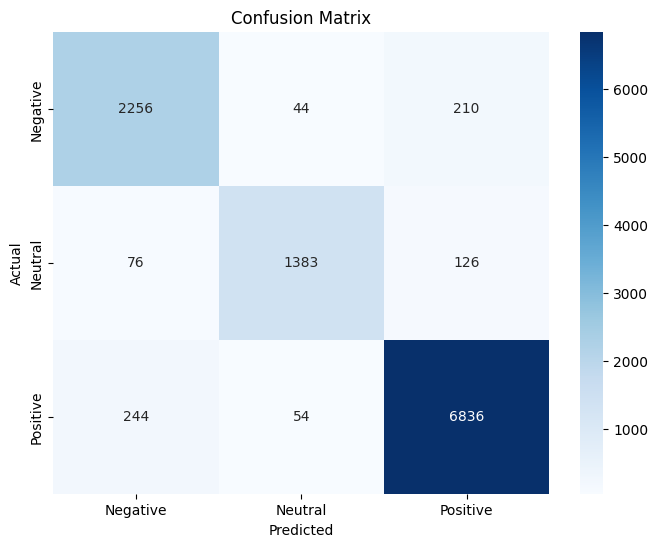

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Display confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [7]:
# Save the model
model.save('sentiment_bilstm_model.h5')

print("Model saved successfully!")

Model saved successfully!
